<a href="https://colab.research.google.com/github/asafbigel/NLP_projects/blob/main/Text-Classification-Benchmarks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###################################################
# Exercise 2 - Natural Language Processing 67658  #
###################################################

# Setup

In [21]:
!pip install evaluate

In [22]:
import numpy as np
from sklearn.datasets import fetch_20newsgroups
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.utils.data import DataLoader
import evaluate
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

In [23]:
# subset of categories that we will use
category_dict = {'comp.graphics': 'computer graphics',
                 'rec.sport.baseball': 'baseball',
                 'sci.electronics': 'science, electronics',
                 'talk.politics.guns': 'politics, guns'
                 }

In [24]:
def get_data(categories=None, portion=1.):
    """
    Get data for given categories and portion
    :param portion: portion of the data to use
    :return:
    """
    # get data
    data_train = fetch_20newsgroups(categories=categories, subset='train', remove=('headers', 'footers', 'quotes'),
                                    random_state=21)
    data_test = fetch_20newsgroups(categories=categories, subset='test', remove=('headers', 'footers', 'quotes'),
                                   random_state=21)

    # train
    train_len = int(portion*len(data_train.data))
    x_train = np.array(data_train.data[:train_len])
    y_train = data_train.target[:train_len]
    # remove empty entries
    non_empty = x_train != ""
    x_train, y_train = x_train[non_empty].tolist(), y_train[non_empty].tolist()

    # test
    x_test = np.array(data_test.data)
    y_test = data_test.target
    non_empty = np.array(x_test) != ""
    x_test, y_test = x_test[non_empty].tolist(), y_test[non_empty].tolist()
    return x_train, y_train, x_test, y_test

# Q1,2

In [25]:
class Dataset(torch.utils.data.Dataset):
        """
        Dataset for loading data
        """
        def __init__(self, x_train, y_train):
            self.x_train = x_train
            self.y_train = y_train
        def __getitem__(self, idx):
            return self.x_train[idx], self.y_train[idx]
        def __len__(self):
            return len(self.x_train)

In [26]:
class DataLoaders(torch.utils.data.DataLoader):
  """
  DataLoaders for loading data
  """
  def __init__(self, dataset, batch_size=16, shuffle=True):
    super().__init__(dataset, batch_size=batch_size, shuffle=shuffle)

In [27]:
class MLP(torch.nn.Module):
  """
  Single Layer Perceptron
  """
  def __init__(self, single_layer:bool):
    super().__init__()
    if single_layer:
      self.net = torch.nn.Linear(2000, 4)
    else:
      self.net = torch.nn.Sequential(
          torch.nn.Linear(2000, 500),
          torch.nn.ReLU(),
          torch.nn.Linear(500, 4)
          )

  def forward(self, x):
    return self.net(x)

In [28]:
def MLP_classification(portion=1. , single_layer:bool=True, epochs=20):
    """
    Perform linear classification
    :param portion: portion of the data to use
    :return: classification accuracy
    """
    _acc = []
    _loss = []
    x_train, y_train, x_test, y_test = get_data(categories=category_dict.keys(), portion=portion)
    TFIDF = TfidfVectorizer(max_features=2000)
    x_train = TFIDF.fit_transform(x_train)
    x_test = TFIDF.transform(x_test)
    x_train = torch.tensor(x_train.toarray(), dtype=torch.float32)
    x_test = torch.tensor(x_test.toarray(), dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    y_test = torch.tensor(y_test, dtype=torch.long)



    dataset = Dataset(x_train, y_train)
    dataloader = DataLoaders(dataset)

    loss = torch.nn.CrossEntropyLoss()
    model = MLP(single_layer)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    model.train()
    for epoch in range(epochs):
        for x, y in dataloader:
            optimizer.zero_grad()
            y_pred = model(x)
            l = loss(y_pred, y)
            l.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
          l_train = loss(model(x_train), y_train)
          _loss.append(l_train.item())
          y_pred_test = model(x_test).argmax(dim=1)
          _acc.append((y_pred_test == y_test).float().mean().item())

    return _acc, _loss, sum(p.numel() for p in model.parameters() if p.requires_grad)

# Q3

In [29]:
def transformer_classification(portion=1.):

    class Dataset(torch.utils.data.Dataset):
        """
        Dataset for loading data
        """
        def __init__(self, encodings, labels):
            self.encodings = encodings
            self.labels = labels

        def __getitem__(self, idx):
            item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
            return item

        def __len__(self):
            return len(self.labels)

    def train_epoch(model, data_loader, optimizer, dev='cpu'):
        """
        Perform an epoch of training of the model with the optimizer
        :param model:
        :param data_loader:
        :param optimizer:
        :param dev:
        :return: Average loss over the epoch
        """
        model.train()
        total_loss = 0.
        # iterate over batches
        for batch in tqdm(data_loader):
            input_ids = batch['input_ids'].to(dev)
            attention_mask = batch['attention_mask'].to(dev)
            labels = batch['labels'].to(dev)
            optimizer.zero_grad()
            output = model(input_ids, attention_mask=attention_mask, labels=labels)
            l = output.loss
            total_loss += l.item()
            l.backward()
            optimizer.step()
        return total_loss / len(data_loader)

    def evaluate_model(model, data_loader, dev='cpu', metric=None):
        model.eval()
        for batch in tqdm(data_loader):
            input_ids = batch['input_ids'].to(dev)
            attention_mask = batch['attention_mask'].to(dev)
            labels = batch['labels'].to(dev)
            with torch.no_grad():
                output = model(input_ids, attention_mask=attention_mask, labels=labels).logits
            predictions = output.argmax(dim=-1)
            metric.add_batch(predictions=predictions, references=labels)
        res = metric.compute()
        return res['accuracy']

    x_train, y_train, x_test, y_test = get_data(categories=category_dict.keys(), portion=portion)

    # Parameters
    dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    num_labels = len(category_dict)
    epochs = 3
    batch_size = 16
    learning_rate = 5e-5

    # Model, tokenizer, and metric
    model = AutoModelForSequenceClassification.from_pretrained('distilroberta-base', num_labels=num_labels).to(dev)
    tokenizer = AutoTokenizer.from_pretrained('distilroberta-base')
    metric = evaluate.load("accuracy")

    # Datasets and DataLoaders
    train_dataset = Dataset(tokenizer(x_train, truncation=True, padding=True), y_train)
    val_dataset = Dataset(tokenizer(x_test, truncation=True, padding=True), y_test)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    loss = []
    acc = []
    for epoch in range(epochs):
        loss.append(train_epoch(model, train_loader, optimizer, dev))
        acc.append(evaluate_model(model, val_loader, dev, metric))
    return acc, loss, sum(p.numel() for p in model.parameters() if p.requires_grad)

# print functions

In [33]:
def print_table(acc, loss, params_num, title):
  plt.figure(figsize=(16, 8))
  plt.subplot(1, 2, 1)
  plt.plot(acc, label='Accuracy')
  plt.title(f'{title}: Accuracy. Num of params: {params_num}')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(loss, label="Loss")
  plt.title(f'{title}: Loss. Num of params: {params_num}')
  plt.legend()

  plt.tight_layout()
  plt.show()


In [34]:
def print_comparison_table(results):
    # כותרת הטבלה
    header = f"{'Configuration':<45} | {'Portion':<10} | {'Final Acc':<12} | {'Final Loss':<12}"
    separator = "-" * len(header)

    print("\n### Final Results Summary")
    print(separator)
    print(header)
    print(separator)

    for text, acc, loss in results:
        # חילוץ ה-Portion מתוך הטקסט (בהנחה שהפורמט נשמר)
        portion = text.split(",")[0].split(":")[1].strip()
        model_type = "Single-Layer" if "single layer" in text.lower() else "Multi-Layer"

        final_acc = acc[-1]
        final_loss = loss[-1]

        # הדפסה במבנה עמודות קבוע
        print(f"{model_type:<45} | {portion:<10} | {final_acc:<12.4f} | {final_loss:<12.4f}")

    print(separator)

In [35]:
def print_full_history(results):
    print("\n" + "="*30 + " FULL HISTORY TRACE " + "="*30)

    for text, acc, loss in results:
        print(f"\n> CONFIGURATION: {text}")
        print(f"{'Epoch':<8} | {'Accuracy':<12} | {'Loss':<12}")
        print("-" * 35)

        for i, (a, l) in enumerate(zip(acc, loss)):
            print(f"{i+1:<8} | {a:<12.6f} | {l:<12.6f}")

    print("\n" + "="*80)

# Main

## Q1 - single layer MLP

In [36]:
def Q1(total_acc_loss, portions):
    for p in portions:
        text = f"Portion: {p}, single layer MLP"
        print(text)
        acc , loss, params_num = MLP_classification(portion=p, single_layer=True)
        print_table(acc, loss, params_num, text)
        print(f'Portion {p}, single layer MLP: final accuracy: {acc[-1]}, final loss: {loss[-1]}, num of params: {params_num}')
        total_acc_loss.append((text, acc, loss))
        # print_full_history([(text, acc, loss)])

## Q2 - multi-layer MLP

In [37]:
def Q2(total_acc_loss, portions):
    for p in portions:
        text = f"Portion: {p}, multi-layer MLP"
        print(text)
        acc , loss, params_num = MLP_classification(portion=p, single_layer=False)
        print(f'Portion {p}, multi-layer MLP: final accuracy: {acc[-1]}, final loss: {loss[-1]}, num of params: {params_num}')
        print_table(acc, loss, params_num, text)
        total_acc_loss.append((text, acc, loss))
        # print_full_history([(text, acc, loss)])

## Q3 - Transformer

In [38]:
def Q3(total_acc_loss, portions):
    print("\nTransformer results:")
    for p in portions[:2]:
        text = f"Transformer portion: {p}"
        print(text)
        acc , loss, params_num = transformer_classification(portion=p)
        print(f'Transformer portion {p}: final accuracy: {acc[-1]}, final loss: {loss[-1]}, num of params: {params_num}')
        print_table(acc, loss, params_num, text)
        total_acc_loss.append((text, acc, loss))
        # print_full_history([(text, acc, loss)])

## main

Portion: 0.1, single layer MLP


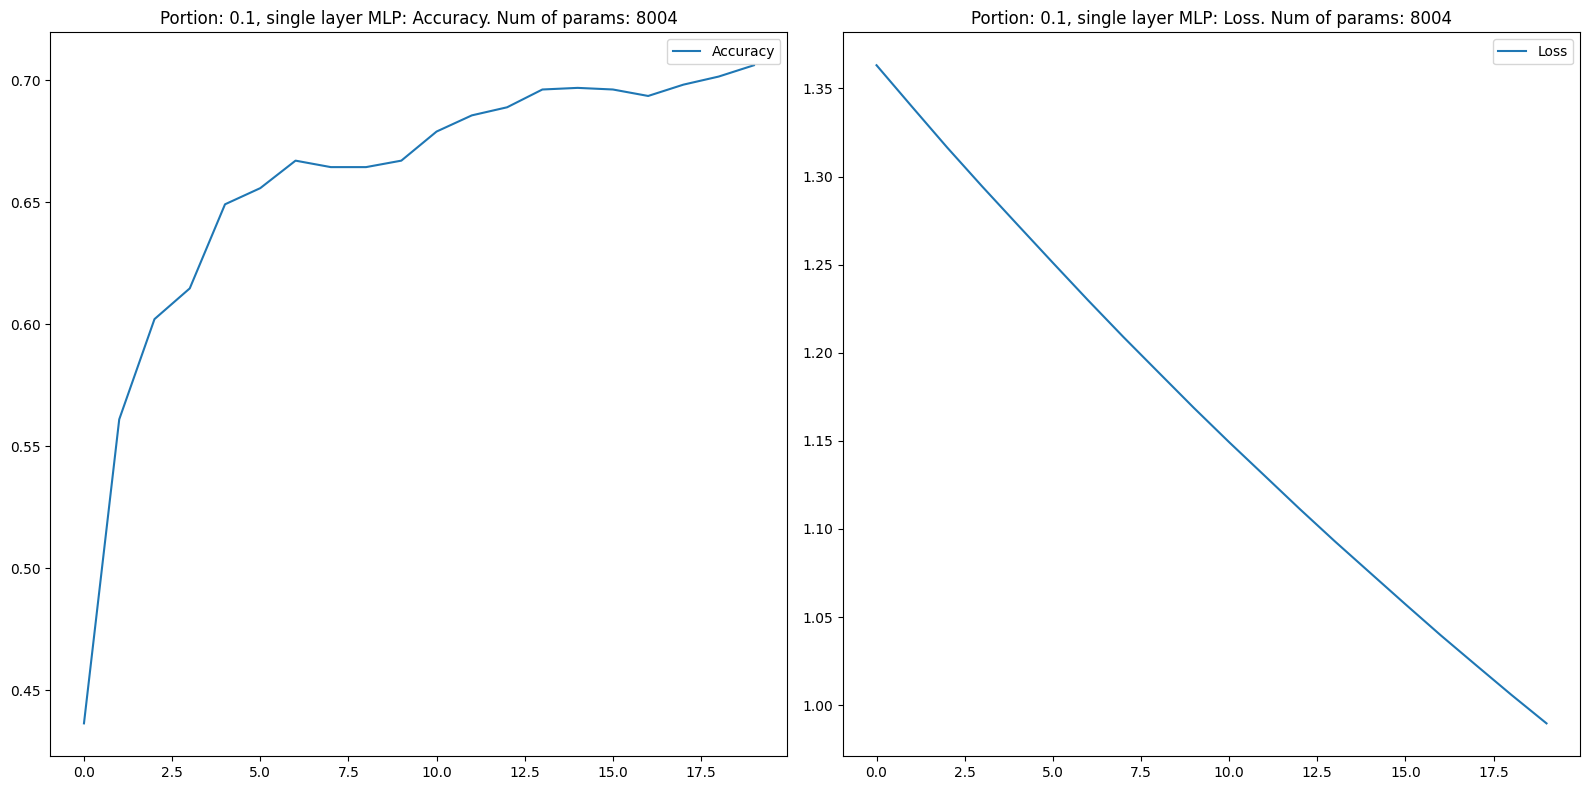

Portion 0.1, single layer MLP: final accuracy: 0.7062334418296814, final loss: 0.9896745085716248, num of params: 8004
Portion: 0.2, single layer MLP


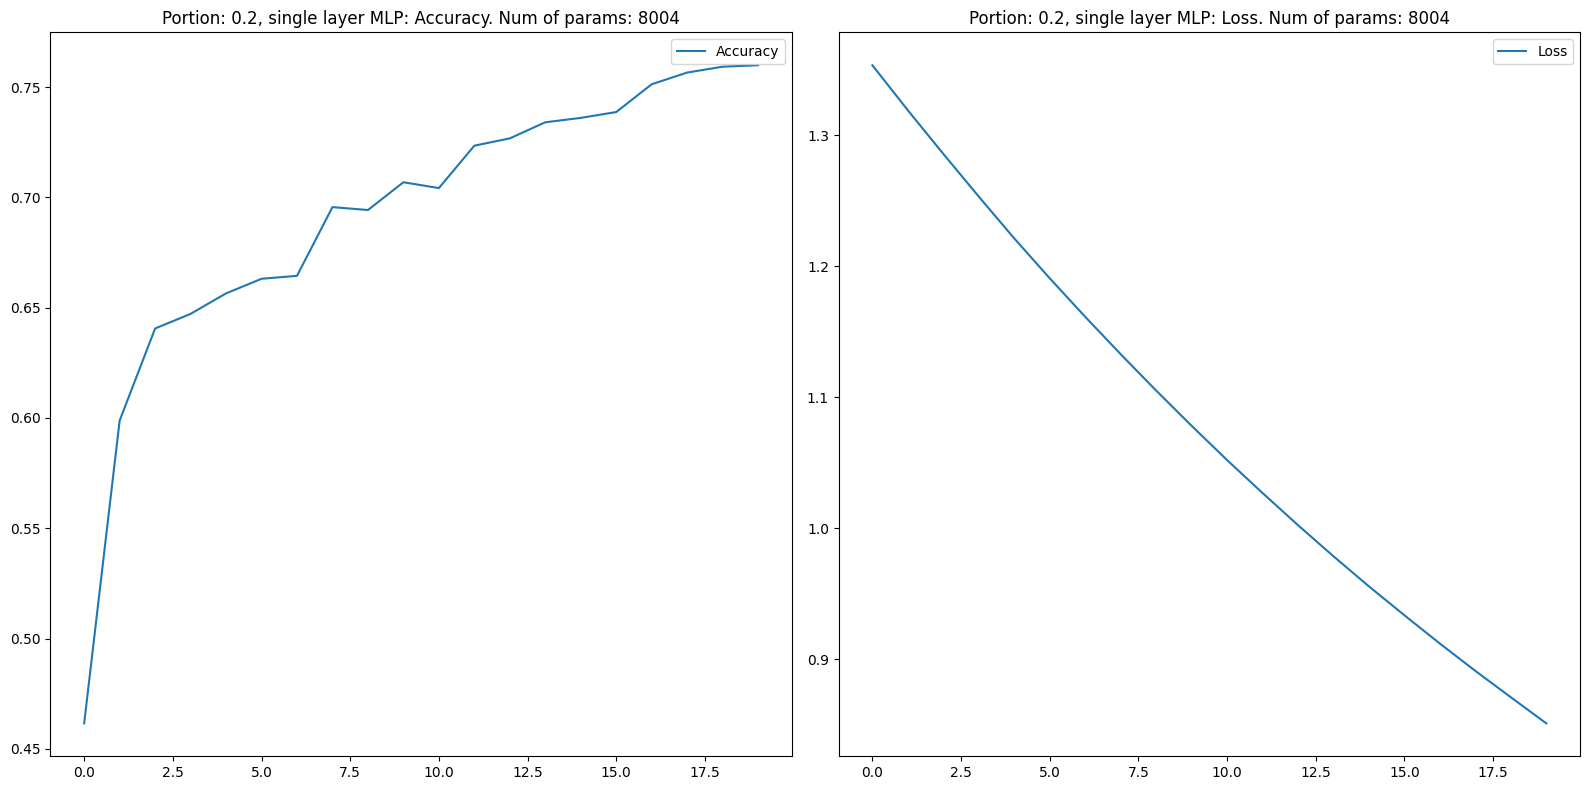

Portion 0.2, single layer MLP: final accuracy: 0.7599469423294067, final loss: 0.850996196269989, num of params: 8004
Portion: 0.5, single layer MLP


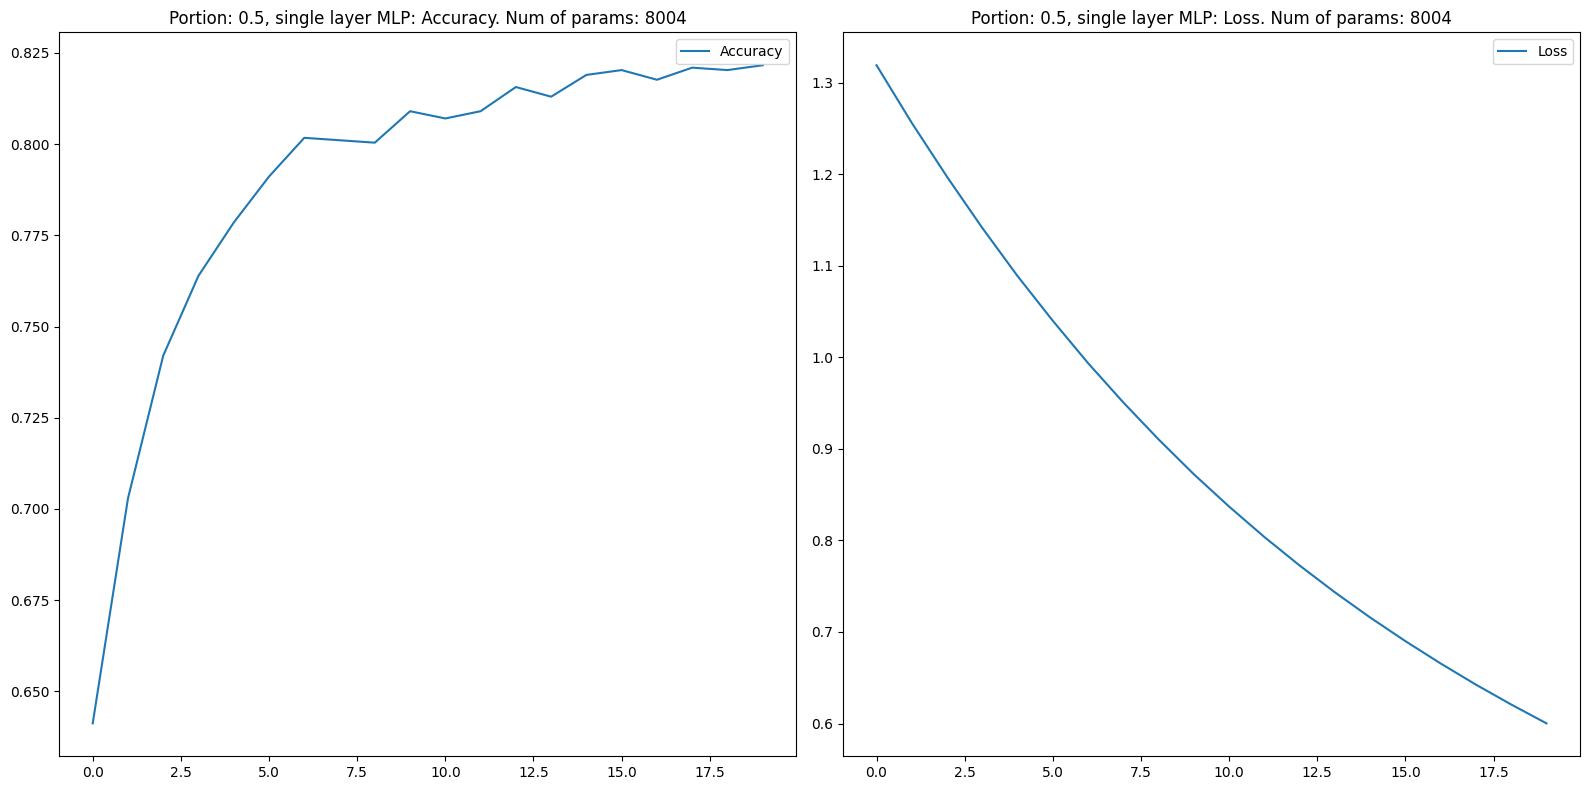

Portion 0.5, single layer MLP: final accuracy: 0.8216180205345154, final loss: 0.600149929523468, num of params: 8004
Portion: 1.0, single layer MLP


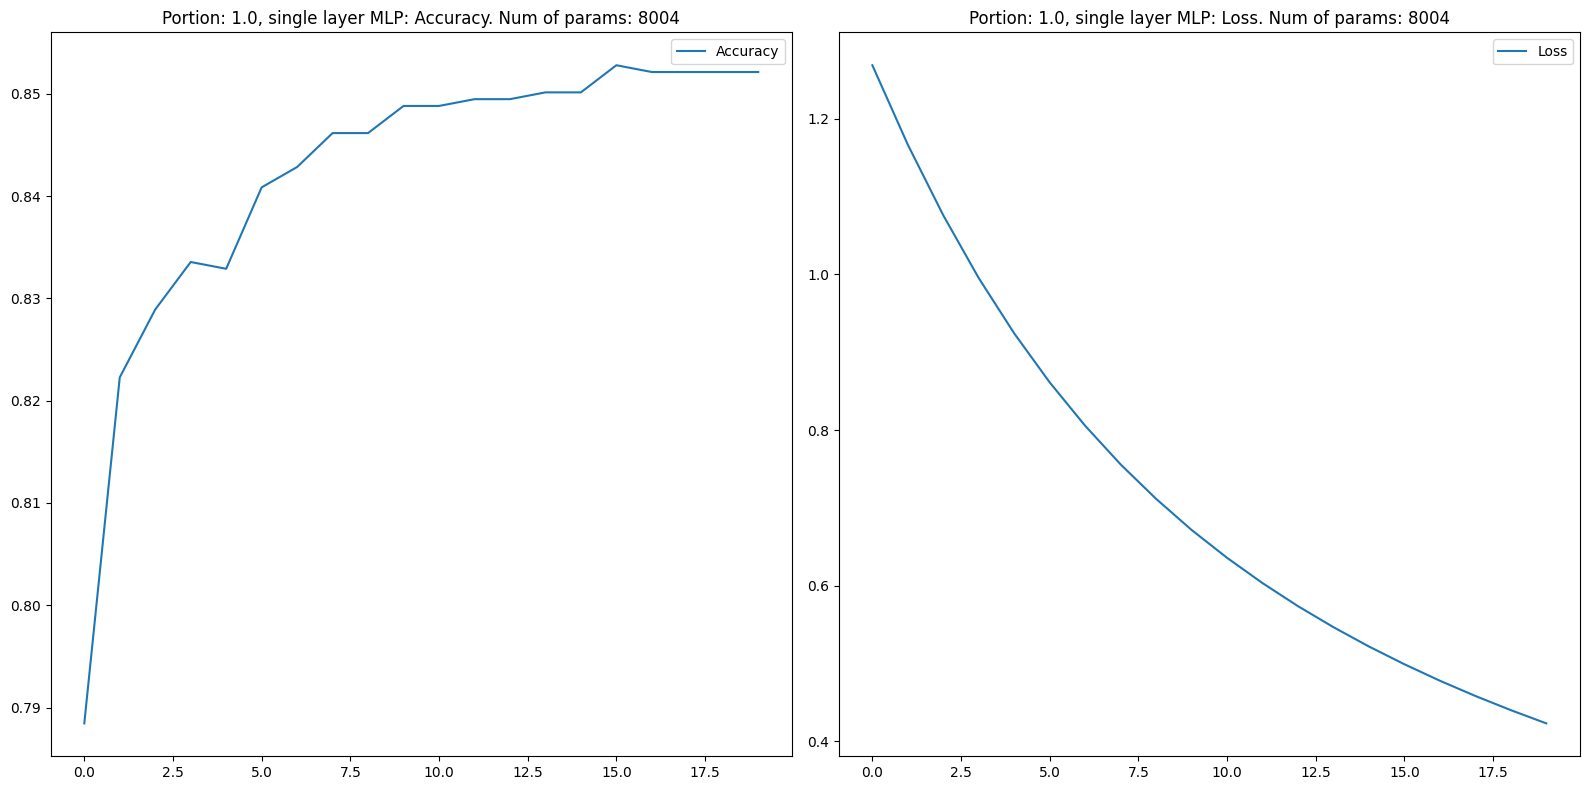

Portion 1.0, single layer MLP: final accuracy: 0.8521220088005066, final loss: 0.42324501276016235, num of params: 8004
Portion: 0.1, multi-layer MLP
Portion 0.1, multi-layer MLP: final accuracy: 0.7314323782920837, final loss: 0.00822688639163971, num of params: 1002504


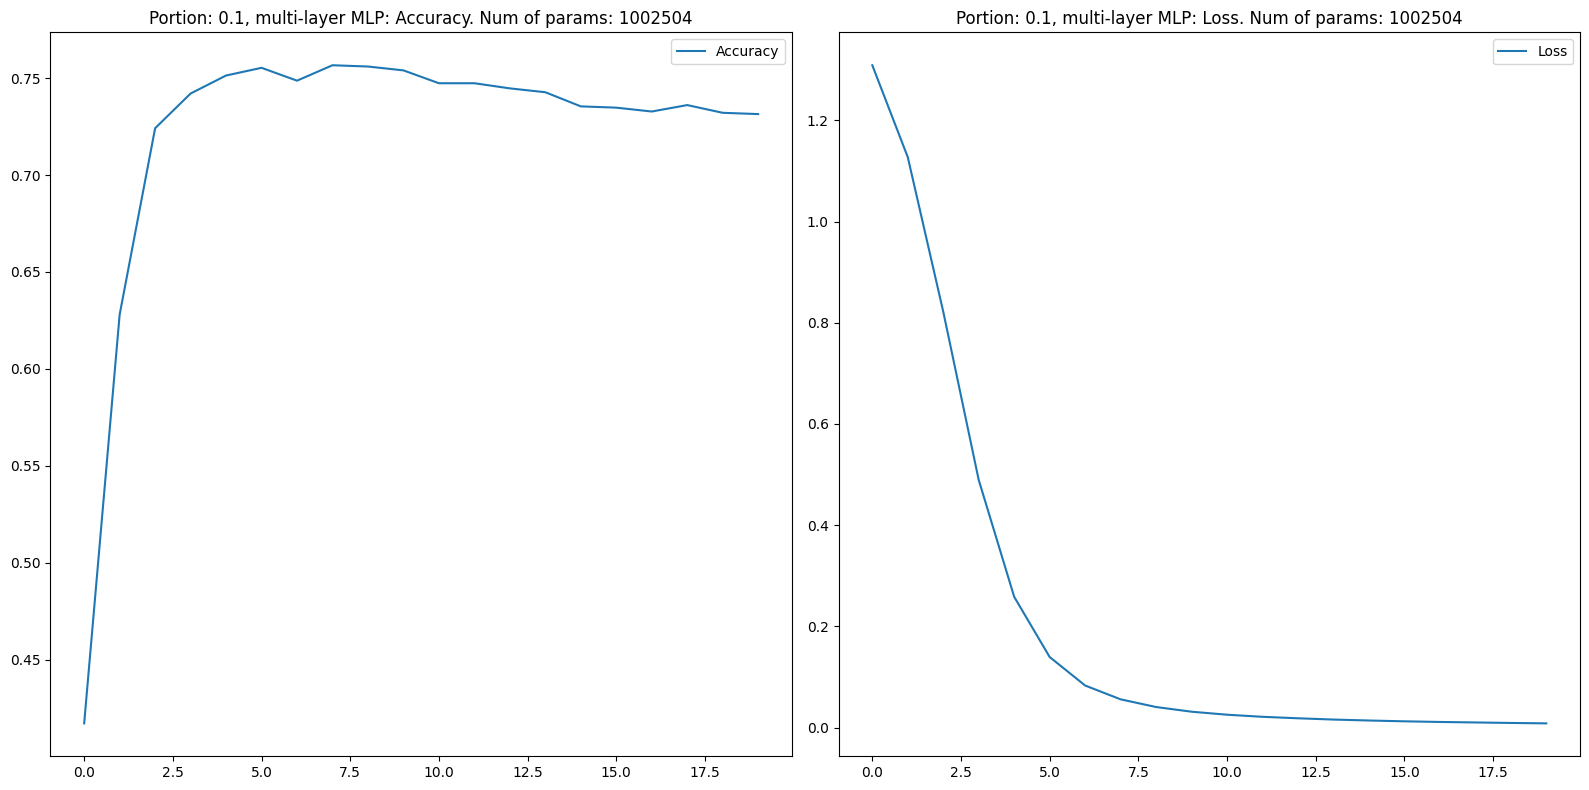

Portion: 0.2, multi-layer MLP
Portion 0.2, multi-layer MLP: final accuracy: 0.790450930595398, final loss: 0.006606724578887224, num of params: 1002504


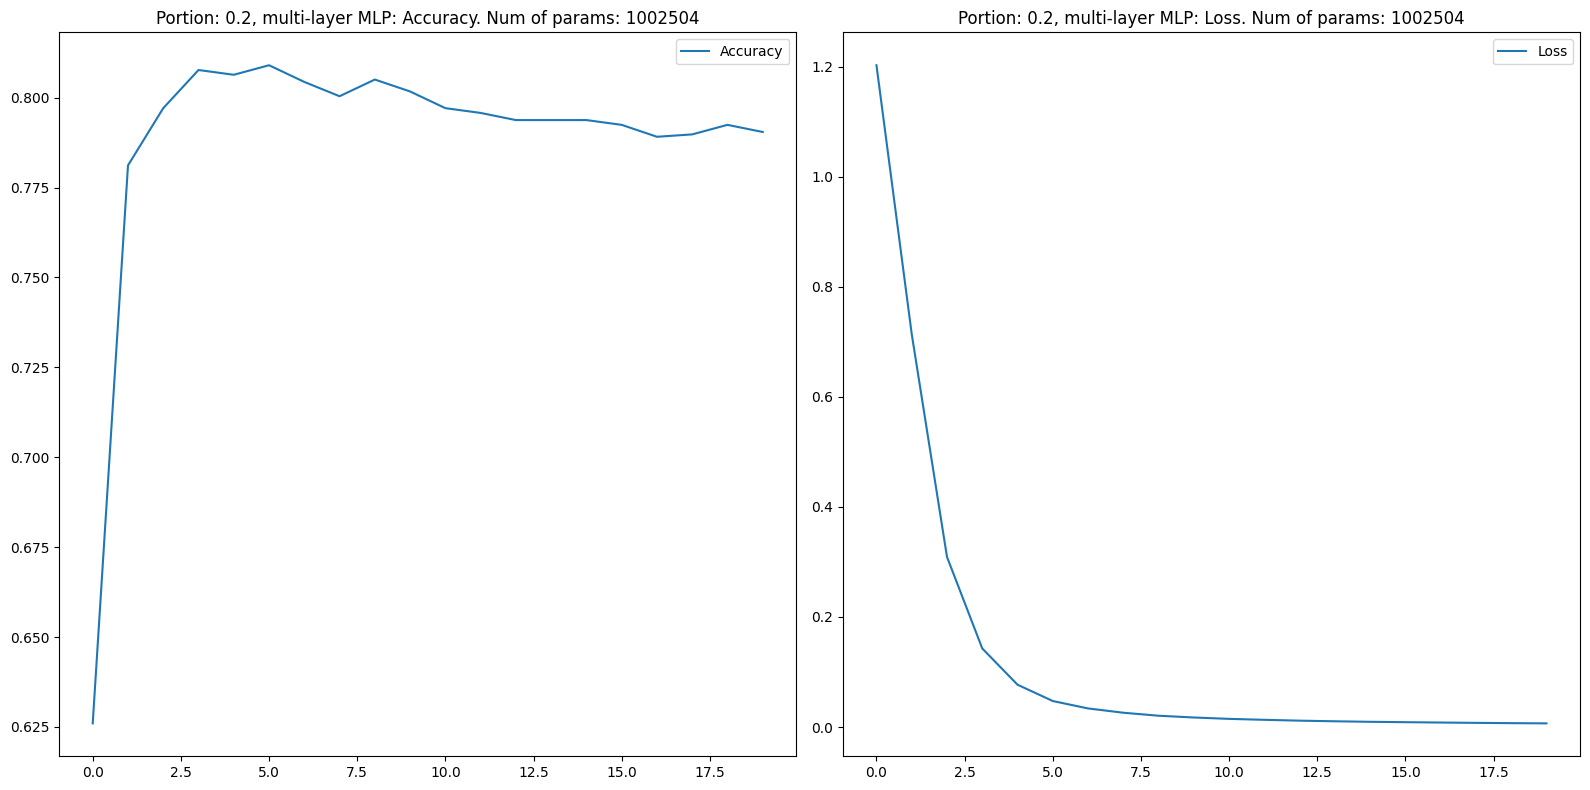

Portion: 0.5, multi-layer MLP
Portion 0.5, multi-layer MLP: final accuracy: 0.8183023929595947, final loss: 0.010102971456944942, num of params: 1002504


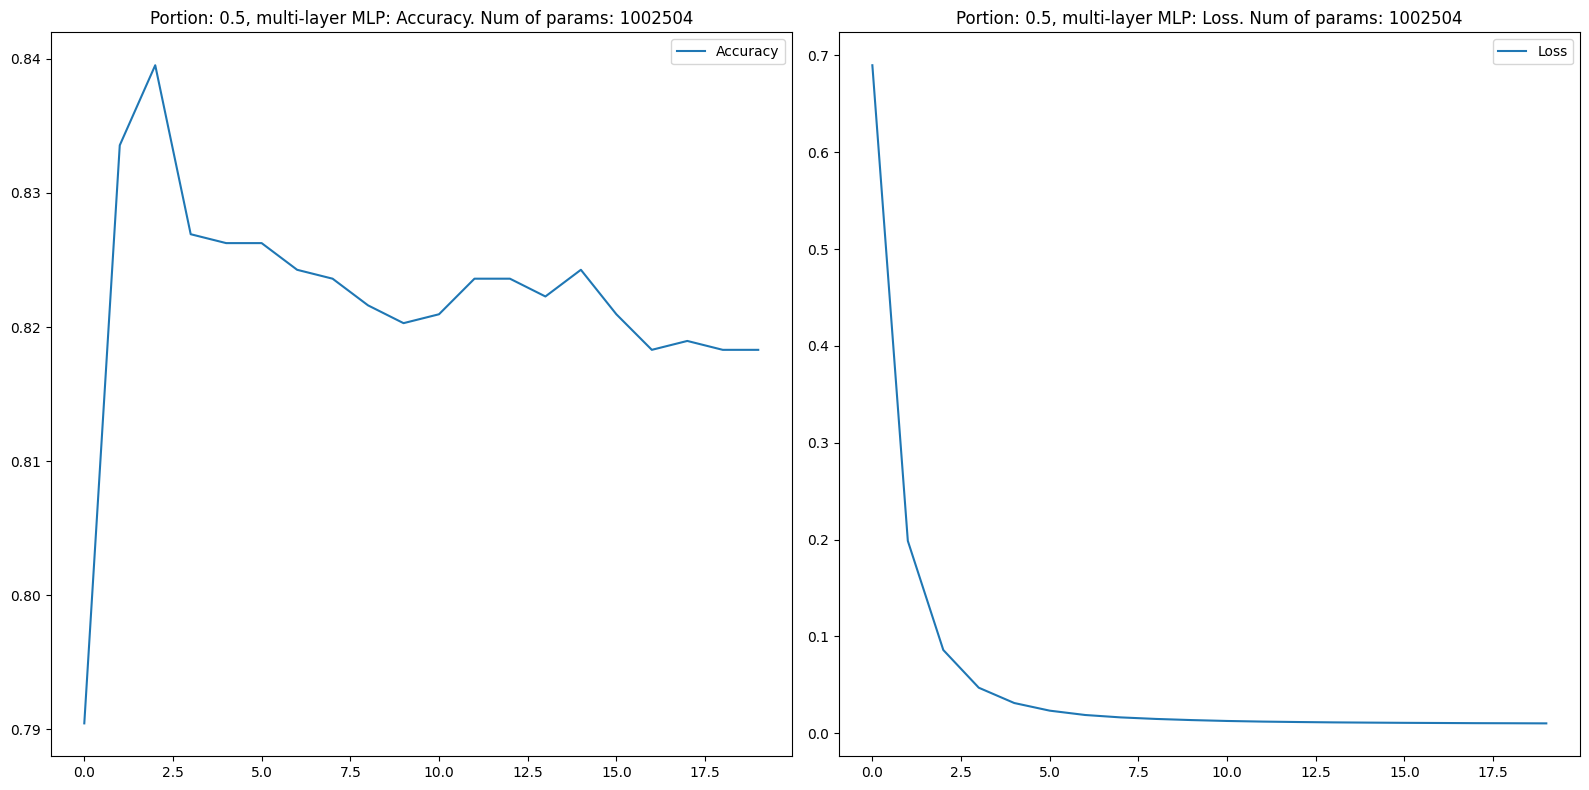

Portion: 1.0, multi-layer MLP
Portion 1.0, multi-layer MLP: final accuracy: 0.8342174887657166, final loss: 0.014518005773425102, num of params: 1002504


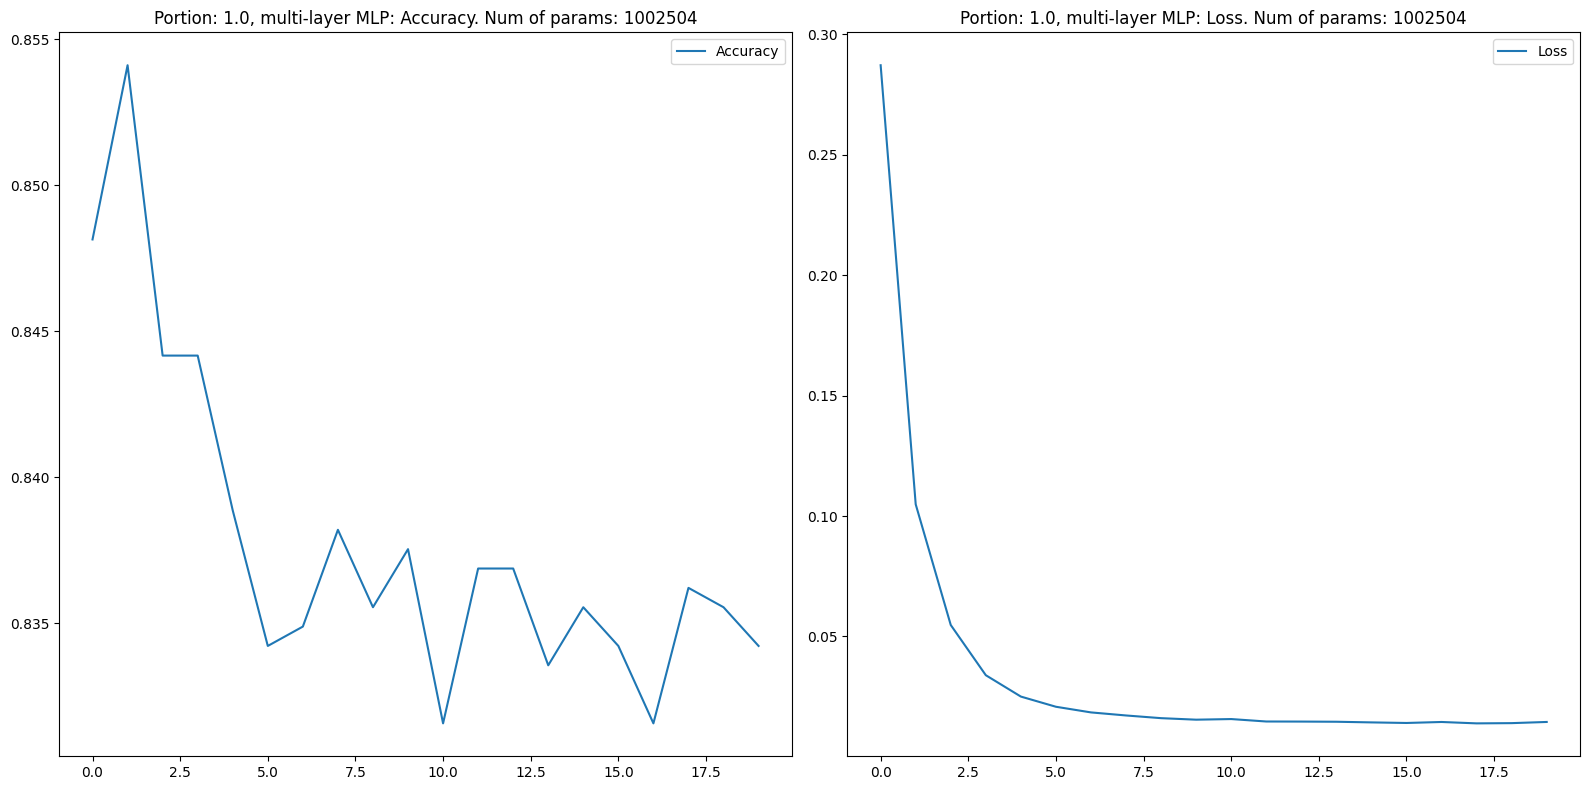


Transformer results:
Transformer portion: 0.1


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
100%|██████████| 95/95 [00:25<00:00,  3.74it/s]


Transformer portion 0.1: final accuracy: 0.8773209549071618, final loss: 0.2632356603940328, num of params: 82121476


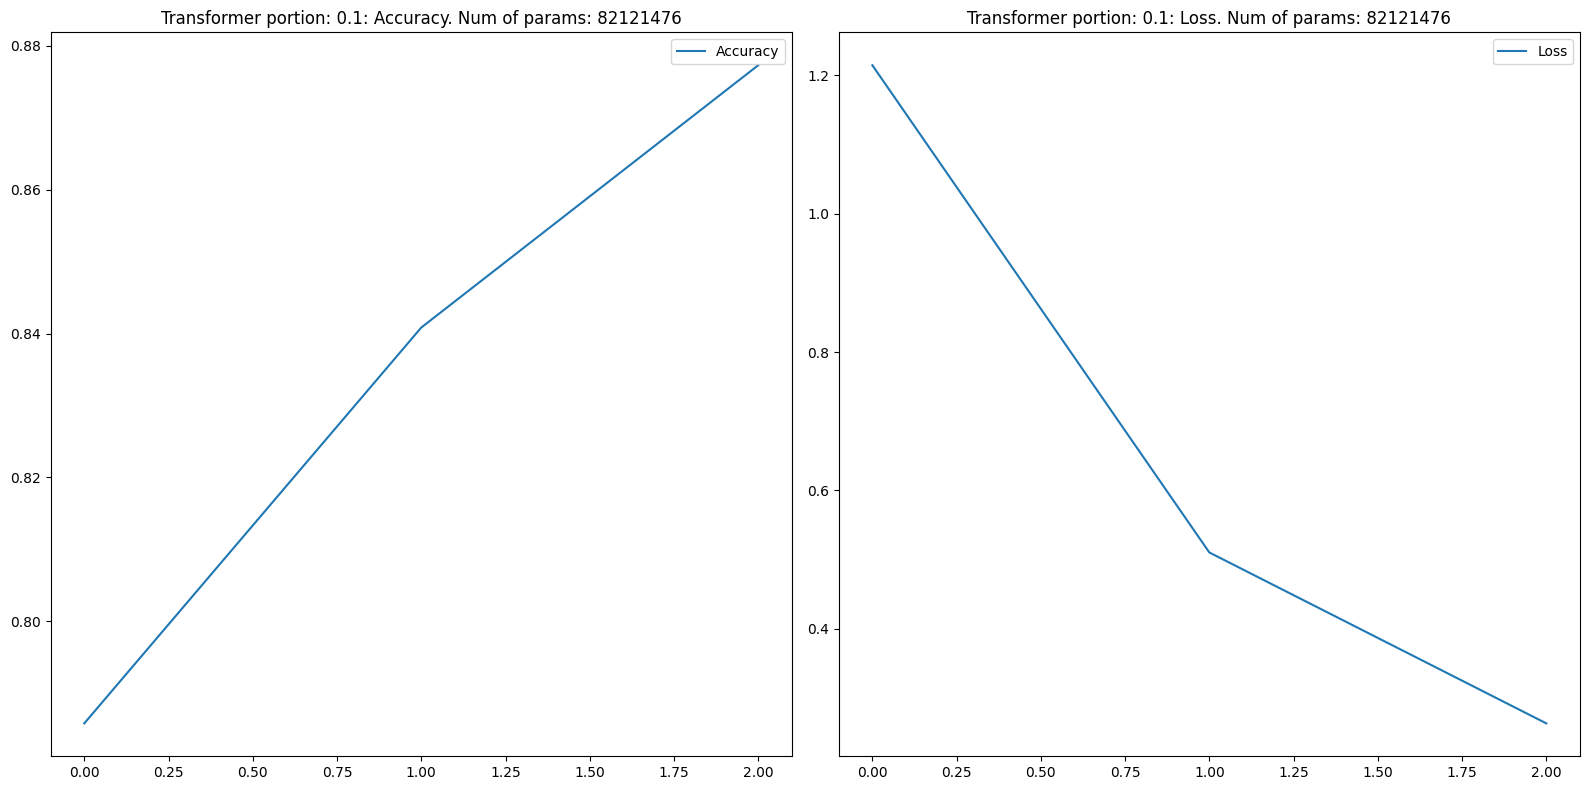

Transformer portion: 0.2


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
100%|██████████| 95/95 [00:25<00:00,  3.71it/s]


Transformer portion 0.2: final accuracy: 0.8806366047745358, final loss: 0.16510089962133045, num of params: 82121476


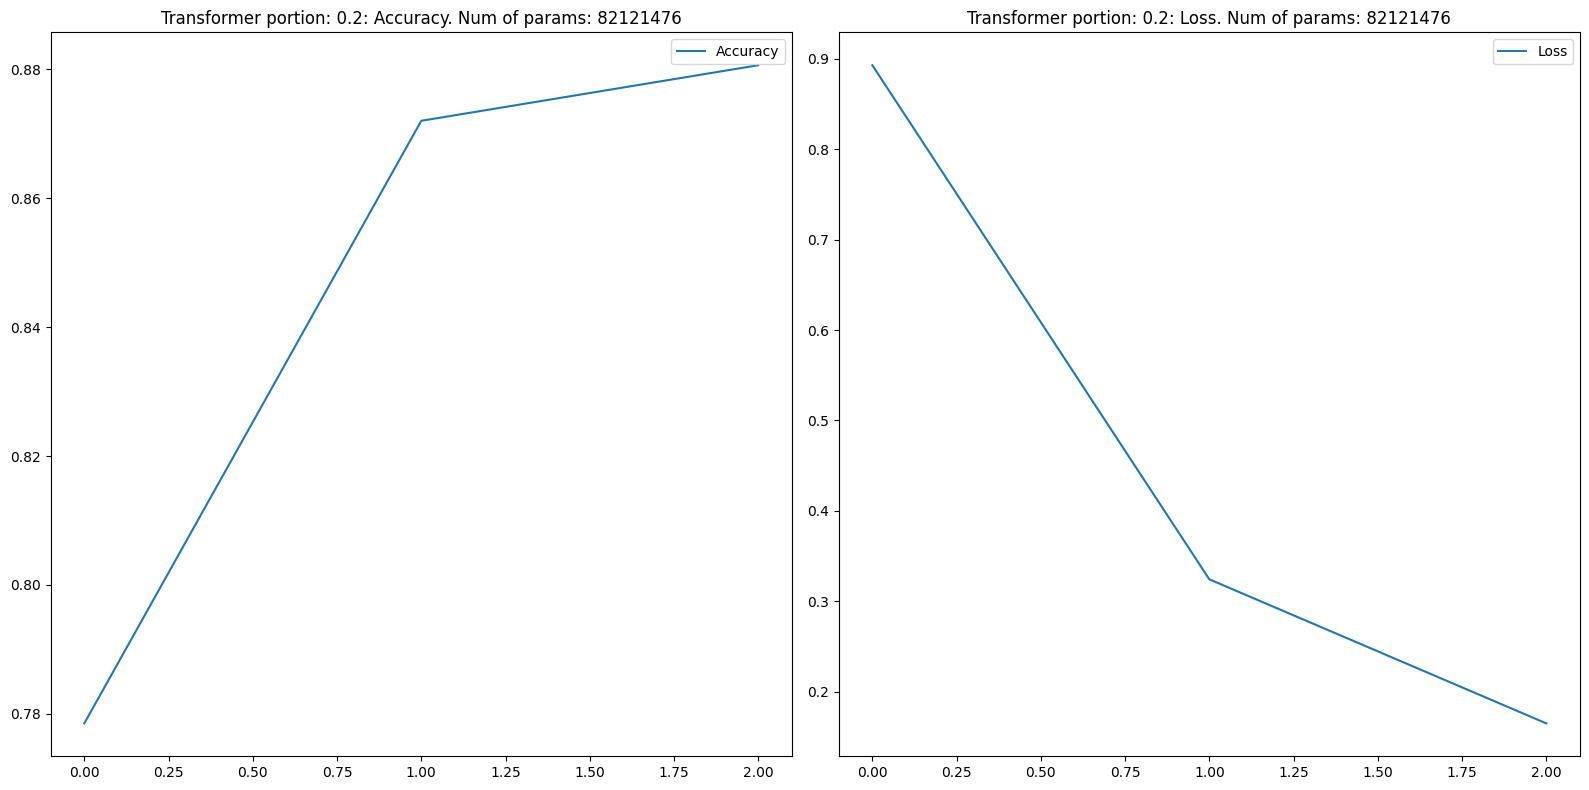

In [39]:
if __name__ == "__main__":
    portions = [0.1, 0.2, 0.5, 1.]
    total_acc_loss = []
    Q1(total_acc_loss, portions)
    Q2(total_acc_loss, portions)
    Q3(total_acc_loss, portions)


    # print_comparison_table(total_acc_loss)
    # print_full_history(total_acc_loss)

In [40]:
print_comparison_table(total_acc_loss)
print_full_history(total_acc_loss)


### Final Results Summary
----------------------------------------------------------------------------------------
Configuration                                 | Portion    | Final Acc    | Final Loss  
----------------------------------------------------------------------------------------
Single-Layer                                  | 0.1        | 0.7062       | 0.9897      
Single-Layer                                  | 0.2        | 0.7599       | 0.8510      
Single-Layer                                  | 0.5        | 0.8216       | 0.6001      
Single-Layer                                  | 1.0        | 0.8521       | 0.4232      
Multi-Layer                                   | 0.1        | 0.7314       | 0.0082      
Multi-Layer                                   | 0.2        | 0.7905       | 0.0066      
Multi-Layer                                   | 0.5        | 0.8183       | 0.0101      
Multi-Layer                                   | 1.0        | 0.8342       | 0.0145 